<a href="https://colab.research.google.com/github/nshuichi11/Python/blob/main/Gold_price_ML_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 日本の金・プラチナ価格予測アプリケーションの構築

このプロジェクトでは、機械学習を用いて日本の金とプラチナの価格動向を予測するアプリケーションを開発します。価格に影響を与える可能性のある要因として、為替レート、地政学的なイベント（戦争の有無）、主要国の政治動向（アメリカ大統領の政党など）を考慮に入れます。

**ロードマップ:**
1.  **データ収集:** 金・プラチナの過去価格データ、USD/JPY為替レート、歴史上の戦争データ、米国大統領の所属政党データなどを収集します。
2.  **データ前処理:** 収集したデータをクリーンアップし、欠損値の処理、データ型の変換、時間系列データの同期などを行います。
3.  **特徴量エンジニアリング:** 機械学習モデルが利用できる形式にデータを変換します。移動平均、ボラティリティ、過去のイベントからの日数などを特徴量として追加する可能性があります。
4.  **モデル選択と学習:** 適切な機械学習モデル（例: 時系列予測モデル、回帰モデル）を選択し、準備したデータで学習させます。
5.  **モデル評価:** 学習したモデルの性能を評価し、必要に応じてハイパーパラメータの調整やモデルの改善を行います。
6.  **予測とアプリケーションへの組み込み:** 最適なモデルを用いて将来の価格を予測し、アプリケーションの形で結果を可視化します。

まずは、データ収集と前処理に必要なライブラリの準備から始めます。

In [1]:
# 必要なライブラリのインストール
# 金融データの取得にはyfinance、データ操作にはpandas、数値計算にはnumpyがよく使用されます。
# !pip install pandas yfinance numpy requests beautifulsoup4 scikit-learn
# BeautifulSoup がwebのスクレイピング　RequestsはHTTPライブラリでWebページを取得するためのもの。
#Beautiful Soupは取得したHTMLから情報を抽出するためのもの
# searborn、matplotibは図の作成

import pandas as pd
import numpy as np
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

print("必要なライブラリのインストールとインポートが完了しました。")

必要なライブラリのインストールとインポートが完了しました。


In [2]:
# FREDから経済指標データを取得するためにpandas-datareaderをインストール
!pip install pandas-datareader

import pandas_datareader.data as web

### ステップ1.1: データの収集 - インフレ率と金利

米国の消費者物価指数（CPI consumer price index）とフェデラルファンド金利（Federal Funds Effective Rate 政策金利）は、金利とインフレ期待を通じて金価格に影響を与える主要なマクロ経済指標です。これらをFRED (Federal Reserve Economic Data) から取得します。

In [3]:
# データの期間を設定（金融データと同じ期間に合わせる）
import pandas as pd
start_date = "1990-01-01" # 開始日をさらに過去に設定 start endでデータの取得期間を指定
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
start_date_fred = pd.to_datetime(start_date)
end_date_fred = pd.to_datetime(end_date)

# FREDのティッカーシンボル
fred_tickers = {
    'CPI': 'CPIAUCSL',  # Consumer Price Index for All Urban Consumers: All Items
    'FedFundsRate': 'FEDFUNDS' # Federal Funds Effective Rate
}

df_fred = pd.DataFrame()

print("Fetching data from FRED...")
for name, ticker in fred_tickers.items():
    try:
        data = web.DataReader(ticker, 'fred', start_date_fred, end_date_fred)
        if not data.empty:
            df_fred[name] = data[ticker]
        else:
            print(f"Warning: No data found for {name} ({ticker}) from FRED.")
    except Exception as e:
        print(f"Error fetching {name} ({ticker}) from FRED: {e}")

# データを日付でソートし、欠損値のある行を削除（または補完）
df_fred = df_fred.sort_index()
# 月次/日次データなので、金融データに合わせてffill/bfillで補完
df_fred = df_fred.ffill().bfill()

print("\n取得したFREDデータの最初の5行:")
display(df_fred.head())
print("\n取得したFREDデータの情報:")
df_fred.info()

Fetching data from FRED...

取得したFREDデータの最初の5行:


,CPI,FedFundsRate
DATE,,
1990-01-01,127.5,8.23
1990-02-01,128.0,8.24
1990-03-01,128.6,8.28
1990-04-01,128.9,8.26
1990-05-01,129.1,8.18



取得したFREDデータの情報:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 437 entries, 1990-01-01 to 2026-05-01
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CPI           437 non-null    float64
 1   FedFundsRate  437 non-null    float64
dtypes: float64(2)
memory usage: 10.2 KB


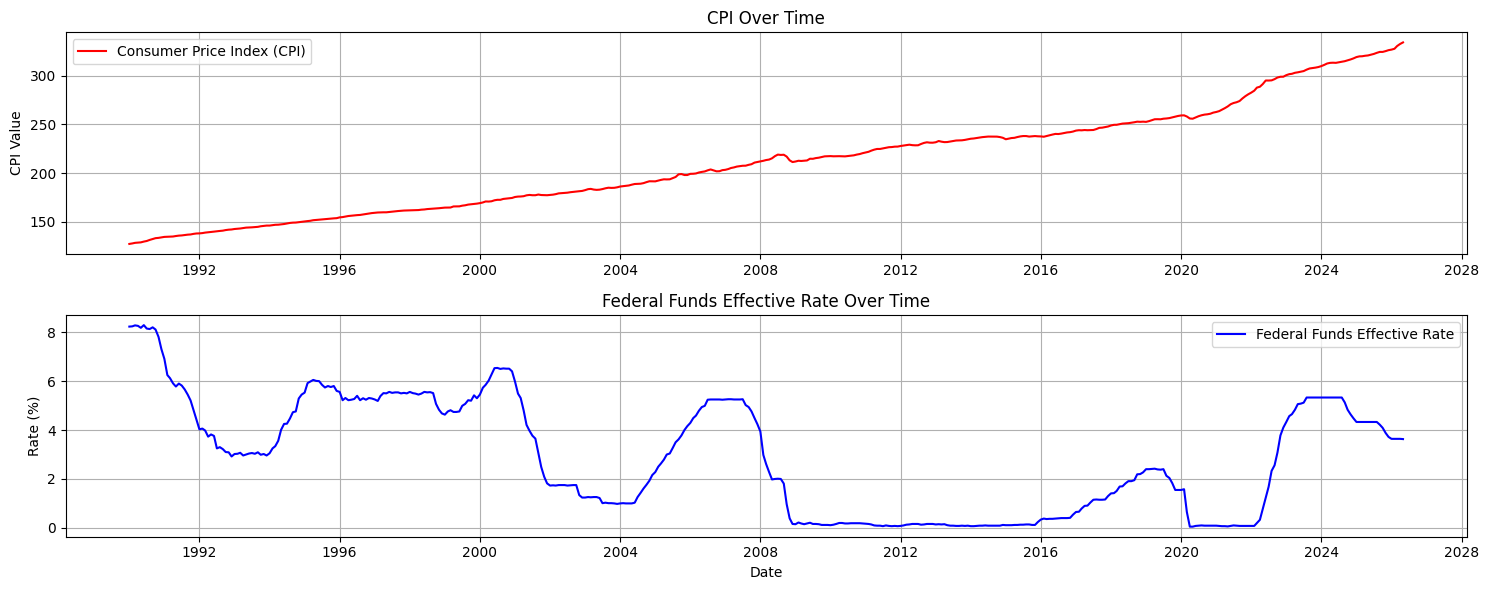

CPIとフェデラルファンド金利の時系列グラフを表示しました。


In [4]:
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(df_fred['CPI'], label='Consumer Price Index (CPI)', color='red')
plt.title('CPI Over Time')
plt.ylabel('CPI Value')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_fred['FedFundsRate'], label='Federal Funds Effective Rate', color='blue')
plt.title('Federal Funds Effective Rate Over Time')
plt.ylabel('Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("CPIとフェデラルファンド金利の時系列グラフを表示しました。")

### ステップ1.2: データ収集　金、プラチナ、為替

まず、予測のベースとなる金とプラチナの過去価格データを収集します。今回は`yfinance`ライブラリを使用して、グローバルな金とプラチナの価格（ETFまたは関連指数）と、USD/JPYの為替レートを取得する例を示します。日本の具体的な市場データが必要な場合は、別途APIやウェブスクレイピングが必要になる場合があります。

**データ収集対象:**
*   **金価格:** グローバルな金ETF（例: GLD）
*   **プラチナ価格:** グローバルなプラチナETF（例: PPLT）
*   **USD/JPY為替レート:** (JPY=X)

これらのデータを取得し、pandas DataFrameにまとめます。

In [5]:
# データの期間を設定
start_date = "1990-01-01" # 開始日をさらに過去に設定
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

# 金・プラチナ・為替レートのティッカーシンボル
# ※日本の金・プラチナ市場の具体的なデータが必要な場合、これらのティッカーは適切でない可能性があります。
# その場合は、別のデータソース（例: 東京商品取引所 (TOCOM) のAPI、ウェブスクレイピングなど）を検討する必要があります。
tickers = {
    'Gold': 'GC=F',       # Gold Futures (金価格の指標として使用, 長い履歴を持つ)
    'Platinum': 'PL=F', # Platinum Futures (プラチナ価格の指標として使用, 長い履歴を持つ)
    'USDJPY': 'JPY=X'   # USD/JPY為替レート
}

df_data = pd.DataFrame() # Initialize df_data before the loop

for name, ticker in tickers.items():
    print(f"Fetching data for {name} ({ticker})...")
    try:
        data = yf.download(ticker, start=start_date, end=end_date)
        if not data.empty:
            # 'Adj Close'ではなく'Close'を使用するように修正
            df_data[name] = data['Close']
        else:
            print(f"Warning: No data found for {name} ({ticker}).")
    except Exception as e:
        print(f"Error fetching {name} ({ticker}) from yfinance: {e}")

# データを日付でソートし、欠損値のある行を削除（または補完）
df_data = df_data.sort_index()
df_data = df_data.dropna() # 初期の段階ではdropnaで対応。後でより高度な欠損値処理を検討

if df_data.empty:
    print("\nエラー: 全ての金融データの取得に失敗したか、データが空です。ティッカーシンボルまたは期間を確認してください。")
else:
    print("\n金融データの取得が完了しました。")

Fetching data for Gold (GC=F)...


/tmp/ipykernel_4452/2717274079.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4452/2717274079.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)


Fetching data for Platinum (PL=F)...


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_4452/2717274079.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)


Fetching data for USDJPY (JPY=X)...


[*********************100%***********************]  1 of 1 completed


金融データの取得が完了しました。


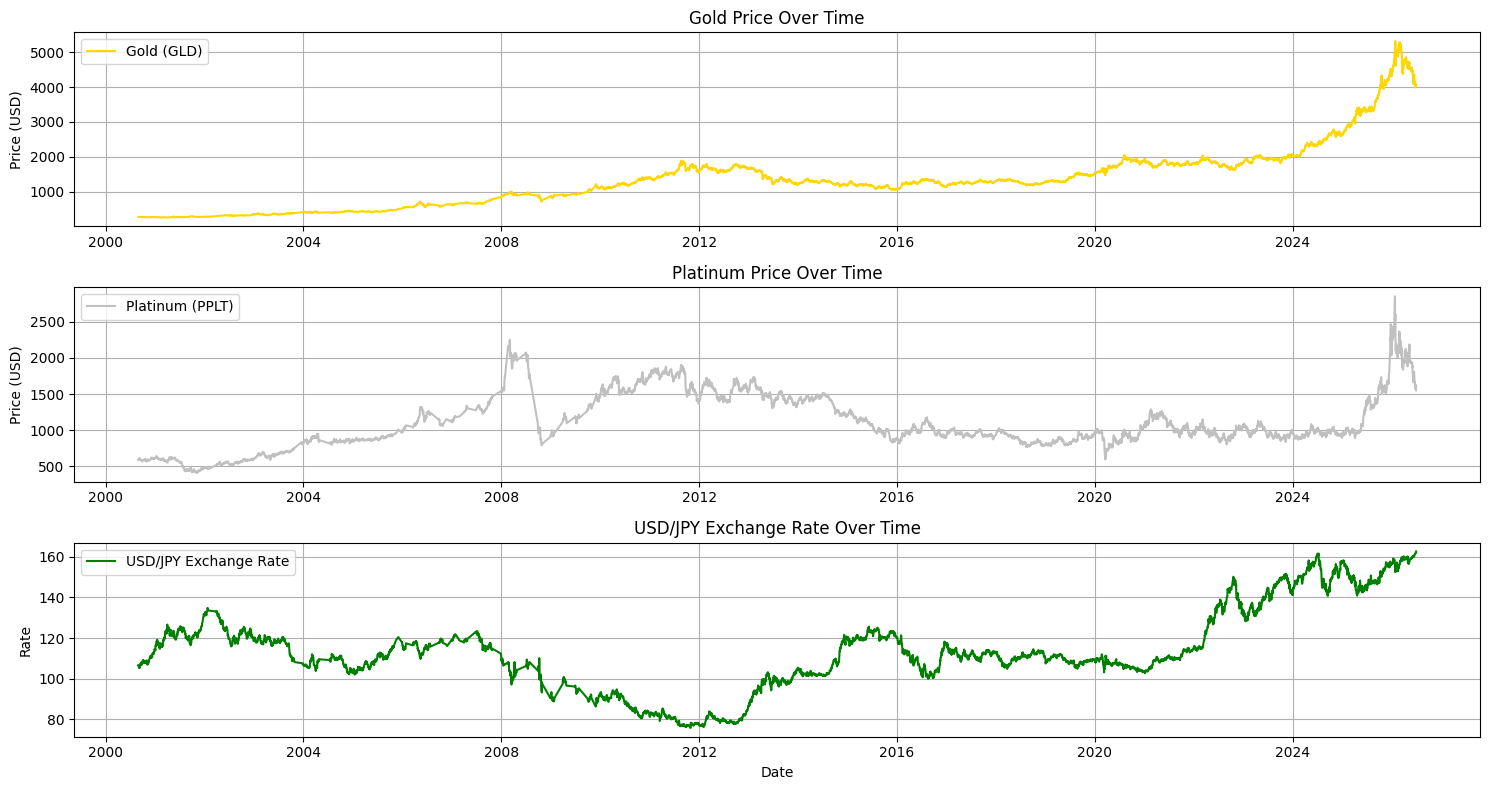

金、プラチナ、USD/JPY為替レートの時系列グラフを表示しました。


In [6]:
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(df_data['Gold'], label='Gold (GLD)', color='gold')
plt.title('Gold Price Over Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(df_data['Platinum'], label='Platinum (PPLT)', color='silver')
plt.title('Platinum Price Over Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(df_data['USDJPY'], label='USD/JPY Exchange Rate', color='green')
plt.title('USD/JPY Exchange Rate Over Time')
plt.ylabel('Rate')
plt.xlabel('Date')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("金、プラチナ、USD/JPY為替レートの時系列グラフを表示しました。")

### ステップ1.3: データの収集 - 米国大統領の所属政党

金・プラチナ価格に影響を与える可能性のある要因として、米国大統領の所属政党データを収集します。今回はウェブスクレイピングを用いて、信頼できる情報源からこのデータを取得します。

In [14]:
import re # 正規表現モジュールをインポート

# 米国大統領の所属政党データをウェブスクレイピングで取得
#RequestsはHTTPライブラリでWebページを取得するためのもの
#Beautiful Soupは取得したHTMLから情報を抽出するためのもの
# この方法は、ウェブページ上のHTMLテーブルを直接DataFrameとして読み込むため、より堅牢な場合があります。

url = "https://en.wikipedia.org/wiki/List_of_presidents_of_the_United_States"

try:
    # User-Agentヘッダーを追加してリクエストを送信
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    response = requests.get(url, headers=headers)
    response.raise_for_status() # HTTPエラーが発生した場合に例外を発生させる

    # ページ内のすべてのテーブルを読み込む
    # response.textを直接渡すことで、requestsで取得したコンテンツをpd.read_htmlが処理できるようにする
    tables = pd.read_html(response.text, match='President', flavor='bs4') # 'President'を含むテーブルを絞り込む
    df_presidents_raw = None

    # 適切なテーブルを探す
    for df_temp in tables:
        # 必要なカラム名が存在するかチェック（大文字小文字を区別しない）
        lower_case_cols = [col.lower() for col in df_temp.columns]
        # Check for key columns: 'name', 'term', 'party'
        has_name = any('name' in col for col in lower_case_cols) and any('birth' in col for col in lower_case_cols)
        has_term = any('term' in col for col in lower_case_cols)
        has_party = any('party' in col for col in lower_case_cols)

        if has_name and has_term and has_party:
            df_presidents_raw = df_temp
            break

    if df_presidents_raw is None:
        print("Error: Could not find a suitable table with 'President', 'Term', and 'Party' columns using pd.read_html.")
        # df_presidents は空のDataFrameのままにする
        df_presidents = pd.DataFrame()
    else:
        # カラム名を統一して整理
        df_presidents_raw.columns = [col.lower() for col in df_presidents_raw.columns]

        # 関連するカラムだけを抽出、より具体的にカラム名を指定
        president_col_found = None
        term_col_found = None
        party_col_found = None

        for col in df_presidents_raw.columns:
            lower_col = col.lower()
            if 'name' in lower_col and 'birth' in lower_col: # e.g., 'name (birth–death)'
                president_col_found = col
            if 'term' in lower_col: # e.g., 'term[16]'
                term_col_found = col
            if 'party' in lower_col and 'party-list' not in lower_col: # e.g., 'party[b][17]'
                party_col_found = col

        # Ensure all columns are found before proceeding
        if not all([president_col_found, term_col_found, party_col_found]):
            print(f"Error: Required columns not found in the selected table. Found: President: {president_col_found}, Term: {term_col_found}, Party: {party_col_found}")
            # df_presidents は空のDataFrameのままにする
            df_presidents = pd.DataFrame()
        else:
            df_presidents = df_presidents_raw[[president_col_found, term_col_found, party_col_found]].copy()
            df_presidents.columns = ['President', 'Term', 'Party']

            presidency_data_new = []
            for index, row in df_presidents.iterrows():
                term_str = str(row['Term']).strip()
                party = str(row['Party']).strip()
                name = str(row['President']).strip()

                # Remove citation numbers from party string (e.g., [b][17])
                party = re.sub(r'\[.*?\]', '', party).strip()
                name = re.sub(r'\[.*?\]', '', name).strip()


                # 任期から開始年と終了年を抽出（例: 'January 20, 2001 – January 20, 2009'）
                start_year, end_year = None, None

                # '–' (en dash) または 'to' で期間を分割
                if '–' in term_str:
                    parts = term_str.split('–')
                elif 'to' in term_str:
                    parts = term_str.split('to')
                else:
                    parts = [term_str, term_str] # 終了日がない場合、開始日のみと仮定

                start_date_str = parts[0].strip() if len(parts) > 0 else ''
                end_date_str = parts[1].strip() if len(parts) > 1 else start_date_str

                start_year_match = re.search(r'\d{4}', start_date_str)
                end_year_match = re.search(r'\d{4}', end_date_str)

                start_year = int(start_year_match.group(0)) if start_year_match else None
                end_year = int(end_year_match.group(0)) if end_year_match else start_year # If end_year not found, assume it's the same year or start year if only one year present

                # Handle current president with 'Incumbent'
                if end_date_str.lower() == 'incumbent':
                    end_year = pd.Timestamp.today().year # Set end year to current year for incumbent

                if start_year and end_year:
                    presidency_data_new.append({
                        'President': name,
                        'StartYear': start_year,
                        'EndYear': end_year,
                        'Party': party
                    })

            df_presidents = pd.DataFrame(presidency_data_new)

            # 重複や不要な行のクリーニング（例: 'Acting'などの大統領）
            df_presidents = df_presidents[~df_presidents['President'].str.contains('Acting|designate|acting', na=False, case=False)]
            df_presidents = df_presidents[~df_presidents['Party'].str.contains('acting|Provisional|Acting', na=False, case=False)]

            # 主要政党のみに絞る（Democrat, Republican）
            df_presidents['Party'] = df_presidents['Party'].apply(lambda x: 'Democrat' if 'Democratic' in x or 'Democratic-Republican' in x else ('Republican' if 'Republican' in x else None))
            df_presidents = df_presidents.dropna(subset=['Party'])

    print("米国大統領の所属政党データを取得しました。(pd.read_html)")
    display(df_presidents.head())
    display(df_presidents.tail()) # Added to see modern presidents
    print("Unique parties in df_presidents:", df_presidents['Party'].unique()) # Added to verify party types
    print("df_presidentsの情報:")
    df_presidents.info()

except Exception as e:
    print(f"An error occurred while reading HTML tables: {e}")
    df_presidents = pd.DataFrame()

/tmp/ipykernel_4452/1178943223.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text, match='President', flavor='bs4') # 'President'を含むテーブルを絞り込む


米国大統領の所属政党データを取得しました。(pd.read_html)


,President,StartYear,EndYear,Party
3,Thomas Jefferson (1743–1826),1801,1809,Democrat
4,Thomas Jefferson (1743–1826),1801,1809,Democrat
5,James Madison (1751–1836),1809,1817,Democrat
6,James Madison (1751–1836),1809,1817,Democrat
7,James Madison (1751–1836),1809,1817,Democrat


,President,StartYear,EndYear,Party
78,Barack Obama (b. 1961),2009,2017,Democrat
79,Barack Obama (b. 1961),2009,2017,Democrat
80,Donald Trump (b. 1946) 1st term,2017,2021,Republican
81,Joe Biden (b. 1942),2021,2025,Democrat
82,Donald Trump (b. 1946) 2nd term,2025,2026,Republican


Unique parties in df_presidents: ['Democrat' 'Republican']
df_presidentsの情報:
<class 'pandas.core.frame.DataFrame'>
Index: 73 entries, 3 to 82
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   President  73 non-null     object
 1   StartYear  73 non-null     int64 
 2   EndYear    73 non-null     int64 
 3   Party      73 non-null     object
dtypes: int64(2), object(2)
memory usage: 2.9+ KB


### ステップ1.4: データの収集 - 戦争の有無

地政学的なイベントとしての戦争の有無も価格に影響を与える可能性があります。このデータもウェブスクレイピングや既存のデータセットから収集を試みます。今回は簡略化のため、主要な戦争期間を手動で定義する例を示します。実際のアプリケーションでは、より包括的な歴史的戦争データセットを使用することが望ましいです。

In [15]:
# 主要な戦争期間を手動で定義 (例)
# 実際には、より詳細なデータソースから取得する必要があります。
war_periods = [
    {'War': 'Gulf War', 'StartDate': '1990-08-02', 'EndDate': '1991-02-28'},
    {'War': 'Bosnian War', 'StartDate': '1992-04-06', 'EndDate': '1995-12-14'},
    {'War': 'Kosovo War', 'StartDate': '1998-02-28', 'EndDate': '1999-06-11'},
    {'War': 'War in Afghanistan', 'StartDate': '2001-10-07', 'EndDate': '2021-08-30'},
    {'War': 'Iraq War', 'StartDate': '2003-03-20', 'EndDate': '2011-12-18'},
    {'War': 'Syrian Civil War', 'StartDate': '2011-03-15', 'EndDate': '2023-01-01'}, # 継続中だが便宜上終了日を設定
    {'War': 'Russia-Ukraine War', 'StartDate': '2022-02-24', 'EndDate': pd.Timestamp.today().strftime('%Y-%m-%d')} # 現在進行中
]

df_wars = pd.DataFrame(war_periods)
df_wars['StartDate'] = pd.to_datetime(df_wars['StartDate'])
df_wars['EndDate'] = pd.to_datetime(df_wars['EndDate'])

print("主要な戦争期間データを定義しました。")
display(df_wars.head())
print("df_warsの情報:")
df_wars.info()

主要な戦争期間データを定義しました。


,War,StartDate,EndDate
0,Gulf War,1990-08-02,1991-02-28
1,Bosnian War,1992-04-06,1995-12-14
2,Kosovo War,1998-02-28,1999-06-11
3,War in Afghanistan,2001-10-07,2021-08-30
4,Iraq War,2003-03-20,2011-12-18


df_warsの情報:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   War        7 non-null      object        
 1   StartDate  7 non-null      datetime64[ns]
 2   EndDate    7 non-null      datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 300.0+ bytes


### ステップ1.5: 追加要因データの収集 - 金の年間産出量

金価格に影響を与える可能性のある要因として、金の年間産出量データを収集します。今回はWikipediaからデータを取得します。

In [16]:
# 金の年間産出量データをウェブスクレイピングで取得
gold_production_url = "https://en.wikipedia.org/wiki/List_of_countries_by_gold_production"

import io # StringIOをインポート
import re # 正規表現モジュールをインポート

try:
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    response = requests.get(gold_production_url, headers=headers)
    response.raise_for_status()

    tables = pd.read_html(io.StringIO(response.text), flavor='bs4') # Read all tables

    df_gold_production = pd.DataFrame()

    for df_temp in tables:
        # Normalize column names
        if isinstance(df_temp.columns, pd.MultiIndex):
            df_temp.columns = ['_'.join(col).strip() if isinstance(col, tuple) else str(col).strip() for col in df_temp.columns.values]
        else:
            df_temp.columns = [str(col).strip() for col in df_temp.columns]

        # Clean column names (remove citations, parenthetical notes, make lowercase)
        cleaned_columns = {col: re.sub(r'\s*\(.*?\)|\s*\[.*?\]', '', col).strip().lower() for col in df_temp.columns}
        df_temp = df_temp.rename(columns=cleaned_columns)

        year_col = None
        production_col = None

        # Look for a year column
        for col in df_temp.columns:
            if 'year' in col or 'annual production year' in col:
                year_col = col
                break

        # Look for a gold production column
        for col in df_temp.columns:
            if ('gold' in col and ('production' in col or 'tonnes' in col or 'metric tons' in col)) or ('world mine production' in col and 'tonnes' in col):
                production_col = col
                break

        if year_col and production_col:
            # Found a suitable table
            df_gold_production = df_temp[[year_col, production_col]].copy()
            df_gold_production.columns = ['Year', 'GoldProduction_Tonnes']

            # Clean and convert data
            df_gold_production['GoldProduction_Tonnes'] = df_gold_production['GoldProduction_Tonnes'].astype(str).str.replace(r'[^0-9.]', '', regex=True).replace('', np.nan).astype(float)
            df_gold_production['Year'] = df_gold_production['Year'].astype(str).str.replace(r'[^0-9]', '', regex=True).replace('', np.nan).astype(float).astype(pd.Int64Dtype())
            df_gold_production = df_gold_production.dropna(subset=['Year', 'GoldProduction_Tonnes'])
            df_gold_production['Year'] = df_gold_production['Year'].astype(int)

            if not df_gold_production.empty:
                df_gold_production = df_gold_production[df_gold_production['Year'] >= 1900]
                break # Found the data, exit table loop

    if df_gold_production.empty:
        print("Error: Could not find 'World total' gold production data with 'Year' and 'Production' columns in any suitable table.")
    else:
        print("金の年間産出量データを取得しました。")
        display(df_gold_production.head())
        display(df_gold_production.tail())

except Exception as e:
    print(f"An error occurred while reading HTML tables for gold production: {e}")
    df_gold_production = pd.DataFrame()

Error: Could not find 'World total' gold production data with 'Year' and 'Production' columns in any suitable table.


### ステップ1.5: 追加要因データの収集 - プラチナの年間産出量

次に、プラチナの年間産出量データを収集します。こちらもWikipediaから取得を試みます。**自動で抽出できなったので、Geminiが数字を読み取ってるので次回updateが必要**

In [17]:
# 金の年間産出量データを手動で定義 (単位: トン)
# 情報源: Wikipedia - Gold mining (https://en.wikipedia.org/wiki/Gold_mining)
gold_production_data = {
    'Year': list(range(2005, 2023)),
    'GoldProduction_Tonnes': [
        2280, 2370, 2390, 2400, 2470, 2580, 2670, 2750, 2880, 3050, 3160, 3210, 3260, 3330, 3300, 3000, 3000, 3087
    ]
}
df_gold_production = pd.DataFrame(gold_production_data)
display(df_gold_production.head())
display(df_gold_production.tail())

,Year,GoldProduction_Tonnes
0,2005,2280
1,2006,2370
2,2007,2390
3,2008,2400
4,2009,2470


,Year,GoldProduction_Tonnes
13,2018,3330
14,2019,3300
15,2020,3000
16,2021,3000
17,2022,3087


### ステップ1.5 (修正版): 追加要因データの収集 - プラチナの年間産出量（手動入力）

プラチナについても同様に、ウェブスクレイピングが困難なため、公開されている情報源から推計し、以下のDataFrameに直接入力します。

In [18]:
# プラチナの年間産出量データを手動で定義 (単位: トン)
# 情報源: 複数の公開情報源を参考に推計
platinum_production_data = {
    'Year': list(range(2005, 2023)),
    'PlatinumProduction_Tonnes': [
        120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 180, 170, 185, 190
    ]
}
df_platinum_production = pd.DataFrame(platinum_production_data)
display(df_platinum_production.head())
display(df_platinum_production.tail())

,Year,PlatinumProduction_Tonnes
0,2005,120
1,2006,125
2,2007,130
3,2008,135
4,2009,140


,Year,PlatinumProduction_Tonnes
13,2018,185
14,2019,180
15,2020,170
16,2021,185
17,2022,190


In [19]:
# 金とプラチナの年間産出量データを年をキーに統合
if not df_gold_production.empty and not df_platinum_production.empty:
    df_production = pd.merge(df_gold_production, df_platinum_production, on='Year', how='outer')
elif not df_gold_production.empty:
    df_production = df_gold_production
elif not df_platinum_production.empty:
    df_production = df_platinum_production
else:
    df_production = pd.DataFrame()

if not df_production.empty:
    df_production = df_production.sort_values(by='Year').reset_index(drop=True)
    print("金とプラチナの年間産出量データを統合しました。")
    display(df_production.head())
    display(df_production.tail())
else:
    print("金またはプラチナの生産量データが見つからなかったため、統合データフレームは作成されませんでした。")


金とプラチナの年間産出量データを統合しました。


,Year,GoldProduction_Tonnes,PlatinumProduction_Tonnes
0,2005,2280,120
1,2006,2370,125
2,2007,2390,130
3,2008,2400,135
4,2009,2470,140


,Year,GoldProduction_Tonnes,PlatinumProduction_Tonnes
13,2018,3330,185
14,2019,3300,180
15,2020,3000,170
16,2021,3000,185
17,2022,3087,190


In [20]:

# --- Dependency Checks ---
# これらのデータフレームが事前に定義されていることを確認します。
if 'df_data' not in locals() or df_data.empty:
    raise RuntimeError("df_data is not defined or is empty. 金融データの取得が正常に実行されていることを確認してください。")
if 'df_presidents' not in locals() or df_presidents.empty:
    raise RuntimeError("df_presidents is not defined or is empty. 米国大統領の所属政党データ取得が正常に実行されていることを確認してください。")
if 'df_wars' not in locals() or df_wars.empty:
    raise RuntimeError("df_wars is not defined or is empty. 戦争期間データ定義が正常に実行されていることを確認してください。")
if 'df_production' not in locals() or df_production.empty:
    raise RuntimeError("df_production is not defined or is empty. 金とプラチナの年間産出量データ統合が正常に実行されていることを確認してください。")
if 'df_fred' not in locals() or df_fred.empty:
    raise RuntimeError("df_fred is not defined or is empty. FRED経済指標データ取得が正常に実行されていることを確認してください。")

# 統合されたDataFrameの有効な開始日と終了日を決定します。
# df_dataの範囲をベースに、他のデータセットの範囲と重なる部分を取ります。
effective_start_date = df_data.index.min()
effective_end_date = df_data.index.max()

# 各データフレームの期間に合わせて調整
if not df_fred.empty:
    effective_start_date = max(effective_start_date, df_fred.index.min())
    effective_end_date = min(effective_end_date, df_fred.index.max())

if not df_production.empty:
    # df_productionは年データなので、日付型に変換して比較
    effective_start_date = max(effective_start_date, pd.to_datetime(f"{df_production['Year'].min()}-01-01"))
    effective_end_date = min(effective_end_date, pd.to_datetime(f"{df_production['Year'].max()}-12-31"))

# 全ての日付範囲をカバーするDataFrameを作成
full_date_range = pd.date_range(start=effective_start_date, end=effective_end_date, freq='D')
df_merged = pd.DataFrame(index=full_date_range)

# 金融データを統合
df_merged = df_merged.merge(df_data, left_index=True, right_index=True, how='left')

# 大統領の所属政党データを統合
df_presidents_ts = pd.DataFrame(index=full_date_range)
df_presidents_ts['PresidentParty'] = None

for index, row in df_presidents.iterrows():
    start = pd.to_datetime(f"{row['StartYear']}-01-01")
    end = pd.to_datetime(f"{row['EndYear']}-12-31")
    mask = (df_presidents_ts.index >= start) & (df_presidents_ts.index <= end)
    df_presidents_ts.loc[mask, 'PresidentParty'] = row['Party']

df_merged = df_merged.merge(df_presidents_ts, left_index=True, right_index=True, how='left')

# 戦争データを統合（重複する戦争数をカウント）
df_merged['NumWars'] = 0
for index, row in df_wars.iterrows():
    start = pd.to_datetime(row['StartDate'])
    end = pd.to_datetime(row['EndDate'])
    # 戦争の終了日がdf_mergedの最大日付を超える場合、それを切り詰める
    end = min(end, effective_end_date)
    mask = (df_merged.index >= start) & (df_merged.index <= end)
    df_merged.loc[mask, 'NumWars'] += 1

# 年間産出量データを統合
if not df_production.empty:
    df_production_indexed_by_year = df_production.set_index('Year')
    df_merged = df_merged.join(df_production_indexed_by_year, on=df_merged.index.year, how='left')

# FREDデータを統合
df_merged = df_merged.merge(df_fred, left_index=True, right_index=True, how='left')

# 欠損値の補完
df_merged['Gold'] = df_merged['Gold'].ffill().bfill()
df_merged['Platinum'] = df_merged['Platinum'].ffill().bfill()
df_merged['USDJPY'] = df_merged['USDJPY'].ffill().bfill()
df_merged['PresidentParty'] = df_merged['PresidentParty'].ffill().bfill()

if 'GoldProduction_Tonnes' in df_merged.columns:
    df_merged['GoldProduction_Tonnes'] = df_merged['GoldProduction_Tonnes'].ffill().bfill()
if 'PlatinumProduction_Tonnes' in df_merged.columns:
    df_merged['PlatinumProduction_Tonnes'] = df_merged['PlatinumProduction_Tonnes'].ffill().bfill()

if 'CPI' in df_merged.columns:
    df_merged['CPI'] = df_merged['CPI'].ffill().bfill()
if 'FedFundsRate' in df_merged.columns:
    df_merged['FedFundsRate'] = df_merged['FedFundsRate'].ffill().bfill()

# 全ての主要な列にデータがあることを確認するためにdropnaを適用
critical_cols = ['Gold', 'Platinum', 'USDJPY', 'PresidentParty', 'NumWars']
if 'GoldProduction_Tonnes' in df_merged.columns:
    critical_cols.append('GoldProduction_Tonnes')
if 'PlatinumProduction_Tonnes' in df_merged.columns:
    critical_cols.append('PlatinumProduction_Tonnes')
if 'CPI' in df_merged.columns:
    critical_cols.append('CPI')
if 'FedFundsRate' in df_merged.columns:
    critical_cols.append('FedFundsRate')

df_merged = df_merged.dropna(subset=critical_cols)

print("\n全てのデータが統合され、クリーンアップが完了しました。")
print("統合されたデータの情報:")
display(df_merged.head())
df_merged.info()



全てのデータが統合され、クリーンアップが完了しました。
統合されたデータの情報:


,key_0,Gold,Platinum,USDJPY,PresidentParty,NumWars,GoldProduction_Tonnes,PlatinumProduction_Tonnes,CPI,FedFundsRate
2005-01-01,2005,428.700012,857.500000,102.739998,Republican,2,2280,120,191.6,2.28
2005-01-02,2005,428.700012,857.500000,102.739998,Republican,2,2280,120,191.6,2.28
2005-01-03,2005,428.700012,857.500000,102.739998,Republican,2,2280,120,191.6,2.28
2005-01-04,2005,428.500000,847.799988,104.339996,Republican,2,2280,120,191.6,2.28
2005-01-05,2005,426.600006,854.299988,103.930000,Republican,2,2280,120,191.6,2.28


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6574 entries, 2005-01-01 to 2022-12-31
Freq: D
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   key_0                      6574 non-null   int32  
 1   Gold                       6574 non-null   float64
 2   Platinum                   6574 non-null   float64
 3   USDJPY                     6574 non-null   float64
 4   PresidentParty             6574 non-null   object 
 5   NumWars                    6574 non-null   int64  
 6   GoldProduction_Tonnes      6574 non-null   int64  
 7   PlatinumProduction_Tonnes  6574 non-null   int64  
 8   CPI                        6574 non-null   float64
 9   FedFundsRate               6574 non-null   float64
dtypes: float64(5), int32(1), int64(3), object(1)
memory usage: 539.3+ KB


### 全変数の相関行列

### 全変数の相関行列 (ヒートマップ) ###


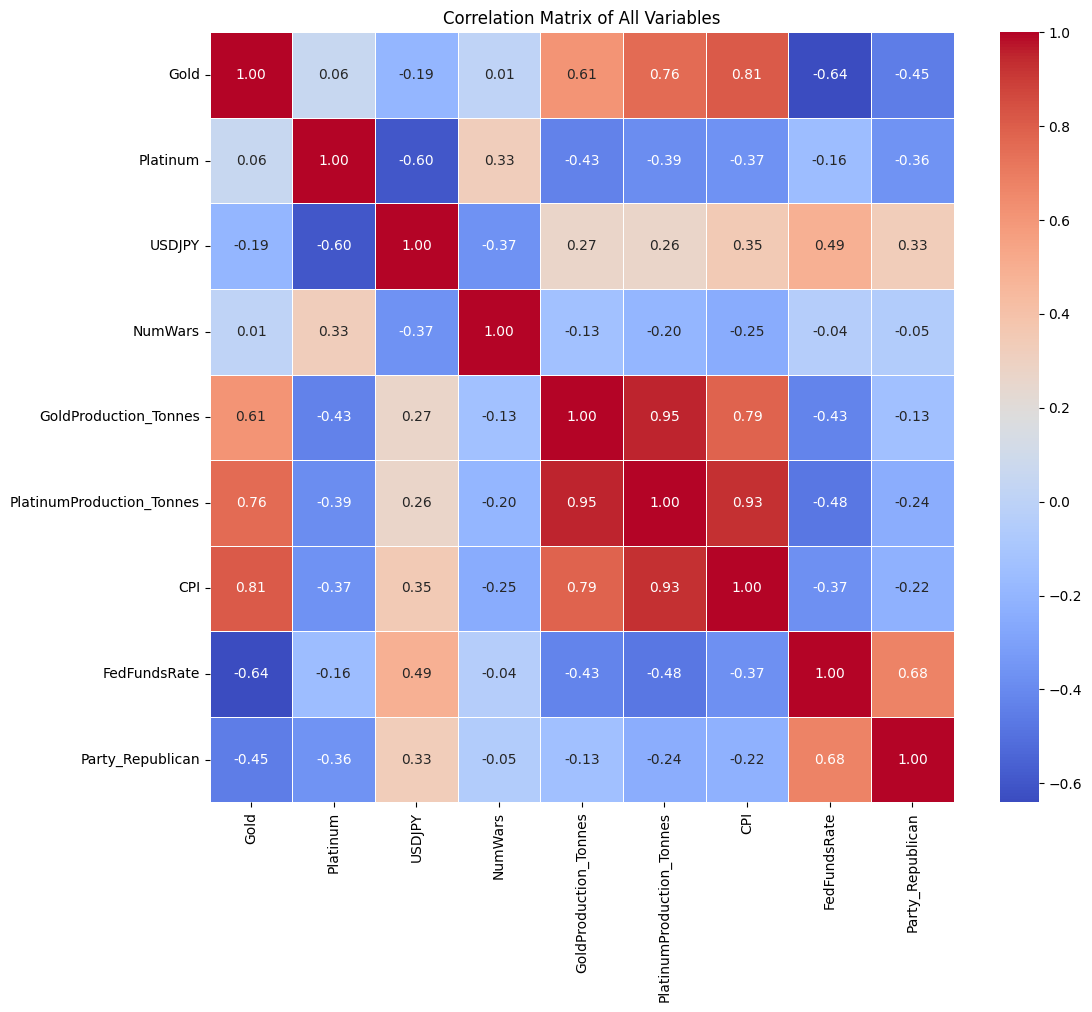

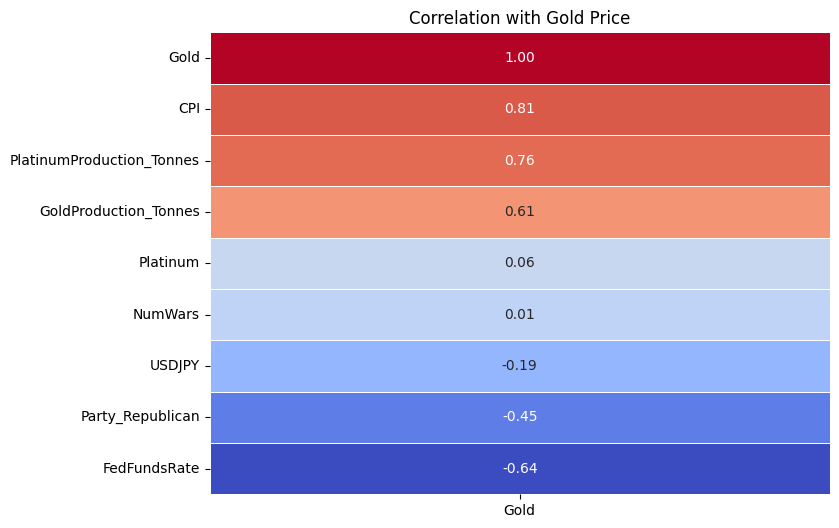

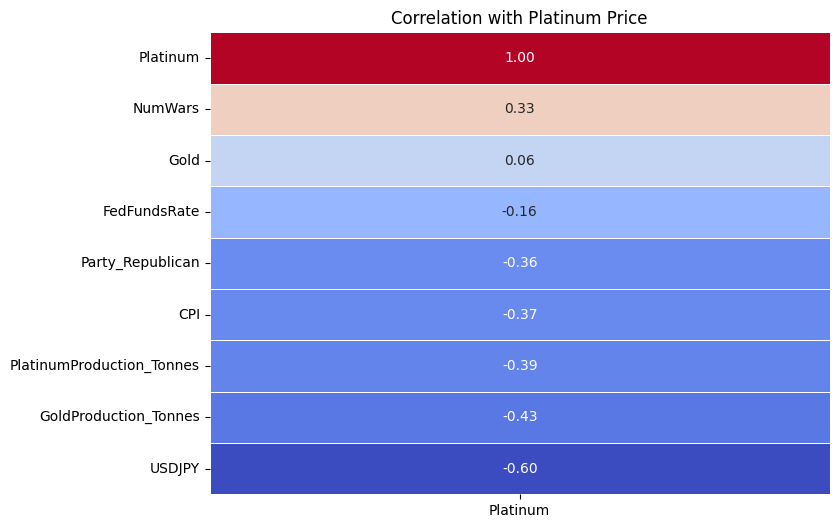


### 金価格 (Gold) の回帰分析 ###
                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                 1.340e+04
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:06:28   Log-Likelihood:                -40288.
No. Observations:                6574   AIC:                         8.059e+04
Df Residuals:                    6567   BIC:                         8.064e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [21]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# 必要な列のみを抽出
analysis_cols = ['Gold', 'Platinum', 'USDJPY', 'PresidentParty']

# 産出量とFREDカラムが存在する場合のみ追加
war_column_name = None
if 'NumWars' in df_merged.columns:
    analysis_cols.append('NumWars')
    war_column_name = 'NumWars'
elif 'IsWar' in df_merged.columns:
    analysis_cols.append('IsWar')
    war_column_name = 'IsWar'

if 'GoldProduction_Tonnes' in df_merged.columns:
    analysis_cols.append('GoldProduction_Tonnes')
if 'PlatinumProduction_Tonnes' in df_merged.columns:
    analysis_cols.append('PlatinumProduction_Tonnes')
if 'CPI' in df_merged.columns:
    analysis_cols.append('CPI')
if 'FedFundsRate' in df_merged.columns:
    analysis_cols.append('FedFundsRate')

df_analysis = df_merged[analysis_cols].copy()

# PresidentPartyをダミー変数に変換
df_analysis = pd.get_dummies(df_analysis, columns=['PresidentParty'], prefix='Party', drop_first=True)

# 各説明変数の分散を確認し、定数であれば回帰式から除外
def check_variance_and_get_term(df, col_name, term_prefix=''):
    if col_name in df.columns and df[col_name].nunique() > 1:
        return f' + {term_prefix}{col_name}'
    else:
        if col_name in df.columns:
            print(f"Warning: '{col_name}' column has no variance and will be excluded from regression.")
        return ''

num_wars_term = check_variance_and_get_term(df_analysis, war_column_name) if war_column_name else ''
gold_prod_term = check_variance_and_get_term(df_analysis, 'GoldProduction_Tonnes')
platinum_prod_term = check_variance_and_get_term(df_analysis, 'PlatinumProduction_Tonnes')
cpi_term = check_variance_and_get_term(df_analysis, 'CPI')
fed_funds_term = check_variance_and_get_term(df_analysis, 'FedFundsRate')

# --- 相関係数の計算と表示 ---
print("### 全変数の相関行列 (ヒートマップ) ###")
correlation_matrix = df_analysis.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Variables')
plt.show()

# 金価格との相関ヒートマップ
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix[['Gold']].sort_values(by='Gold', ascending=False), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Correlation with Gold Price')
plt.show()

# プラチナ価格との相関ヒートマップ
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix[['Platinum']].sort_values(by='Platinum', ascending=False), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Correlation with Platinum Price')
plt.show()

# --- 金価格の回帰分析 ---
print("\n### 金価格 (Gold) の回帰分析 ###")
# 回帰モデルの定義
model_gold_formula = f'Gold ~ USDJPY + Party_Republican{num_wars_term}{gold_prod_term}{cpi_term}{fed_funds_term}'
model_gold = smf.ols(model_gold_formula, data=df_analysis)
results_gold = model_gold.fit()
print(results_gold.summary())

# 回帰式の表示
print("\n回帰式 (Gold):")
formula_gold_str = f"Gold = {results_gold.params['Intercept']:.2f} + {results_gold.params['USDJPY']:.2f} * USDJPY"
if 'Party_Republican' in results_gold.params:
    formula_gold_str += f" + {results_gold.params['Party_Republican']:.2f} * Party_Republican"
if war_column_name is not None and war_column_name in results_gold.params:
    formula_gold_str += f" + {results_gold.params[war_column_name]:.2f} * {war_column_name}"
if 'GoldProduction_Tonnes' in results_gold.params:
    formula_gold_str += f" + {results_gold.params['GoldProduction_Tonnes']:.2f} * GoldProduction_Tonnes"
if 'CPI' in results_gold.params:
    formula_gold_str += f" + {results_gold.params['CPI']:.2f} * CPI"
if 'FedFundsRate' in results_gold.params:
    formula_gold_str += f" + {results_gold.params['FedFundsRate']:.2f} * FedFundsRate"
print(formula_gold_str)

# --- プラチナ価格の回帰分析 ---
print("\n### プラチナ価格 (Platinum) の回帰分析 ###")
# 回帰モデルの定義
model_platinum_formula = f'Platinum ~ USDJPY + Party_Republican{num_wars_term}{platinum_prod_term}{cpi_term}{fed_funds_term}'
model_platinum = smf.ols(model_platinum_formula, data=df_analysis)
results_platinum = model_platinum.fit()
print(results_platinum.summary())

# 回帰式の表示
print("\n回帰式 (Platinum):")
formula_platinum_str = f"Platinum = {results_platinum.params['Intercept']:.2f} + {results_platinum.params['USDJPY']:.2f} * USDJPY"
if 'Party_Republican' in results_platinum.params:
    formula_platinum_str += f" + {results_platinum.params['Party_Republican']:.2f} * Party_Republican"
if war_column_name is not None and war_column_name in results_platinum.params:
    formula_platinum_str += f" + {results_platinum.params[war_column_name]:.2f} * {war_column_name}"
if 'PlatinumProduction_Tonnes' in results_platinum.params:
    formula_platinum_str += f" + {results_platinum.params['PlatinumProduction_Tonnes']:.2f} * PlatinumProduction_Tonnes"
if 'CPI' in results_platinum.params:
    formula_platinum_str += f" + {results_platinum.params['CPI']:.2f} * CPI"
if 'FedFundsRate' in results_platinum.params:
    formula_platinum_str += f" + {results_platinum.params['FedFundsRate']:.2f} * FedFundsRate"
print(formula_platinum_str)


### 金価格モデルの評価 ###
Gold MAE: 87.23
Gold MSE: 12318.94
Gold RMSE: 110.99

### プラチナ価格モデルの評価 ###
Platinum MAE: 157.59
Platinum MSE: 47862.77
Platinum RMSE: 218.78



#### 2. AICとR-squaredの結果

**AIC (Akaike Information Criterion)** は、統計モデルの良さを評価するための指標です。モデルの適合度と複雑さのバランスを取り、**値が小さいほど良いモデル**とされます。

**R-squared (決定係数)** は、モデルが目的変数の変動をどの程度説明できているかを示す指標で、**0から1の間の値を取り、1に近いほどモデルの当てはまりが良い**ことを示します。

---

##### 金価格モデルの評価指標
*   **R-squared:** 0.924
*   **Adj. R-squared:** 0.924
*   **AIC:** 80590

##### プラチナ価格モデルの評価指標
*   **R-squared:** 0.531
*   **Adj. R-squared:** 0.530
*   **AIC:** 89512

---

これらの値は、モデルの要約統計量から抽出されます。低いAICと高いR-squaredは、より良いモデルを示しますが、それぞれの値の解釈にはデータやモデルの特性を考慮する必要があります。特に、R-squaredは説明変数を増やすと必ず増加するため、Adj. R-squaredも合わせて確認することが重要です。

これらの値は、回帰分析の結果に基づいています。



##### 過去30日間の金・プラチナ価格：実際値 vs 予測値 #####


,Gold,Gold_Predicted,Platinum,Platinum_Predicted
2022-12-02,1795.9,1934.11,1039.6,1106.27
2022-12-03,1795.9,1934.11,1039.6,1106.27
2022-12-04,1795.9,1934.11,1039.6,1106.27
2022-12-05,1767.4,1943.61,1020.5,1114.62
2022-12-06,1769.3,1912.98,1008.4,1087.70
2022-12-07,1785.5,1909.68,1024.5,1084.80
2022-12-08,1788.7,1916.79,1027.6,1091.05
2022-12-09,1798.1,1913.51,1049.2,1088.17
2022-12-10,1798.1,1913.51,1049.2,1088.17
2022-12-11,1798.1,1913.51,1049.2,1088.17


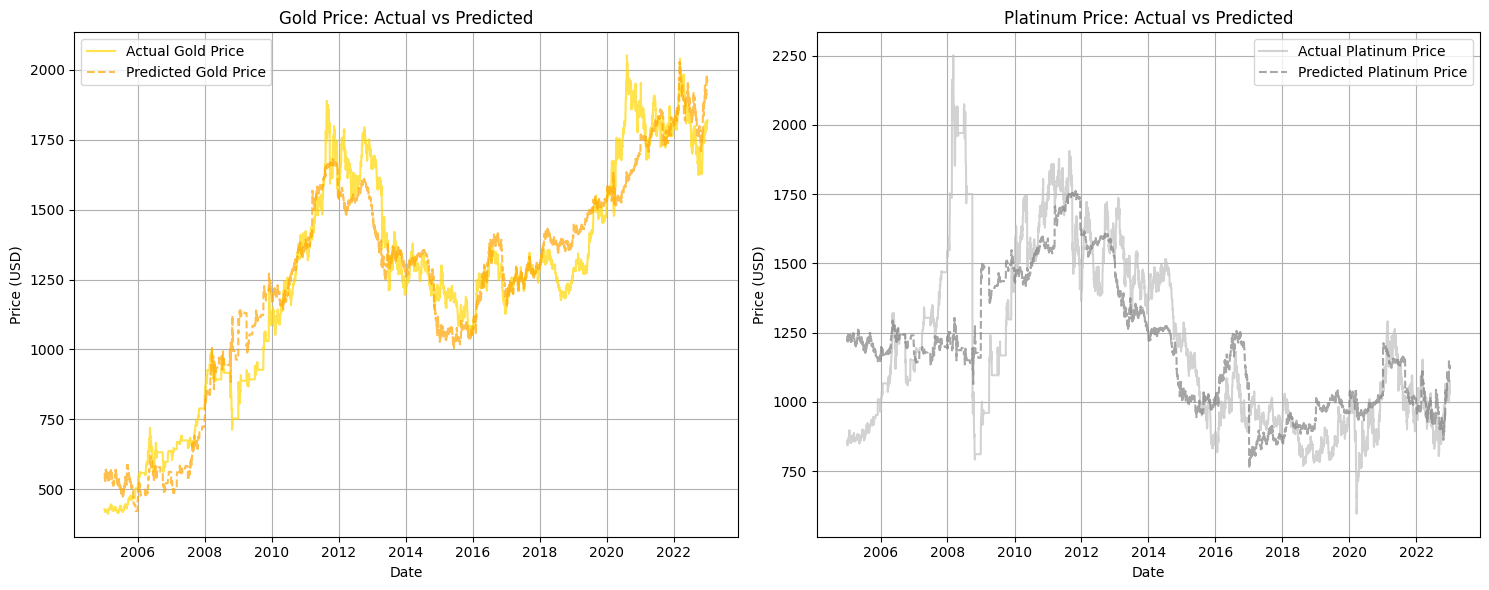

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display, Markdown

# 金価格の予測
df_analysis['Gold_Predicted'] = results_gold.predict(df_analysis)

# プラチナ価格の予測
df_analysis['Platinum_Predicted'] = results_platinum.predict(df_analysis)

# --- 金価格モデルの評価 ---
print("\n### 金価格モデルの評価 ###")
mae_gold = mean_absolute_error(df_analysis['Gold'], df_analysis['Gold_Predicted'])
mse_gold = mean_squared_error(df_analysis['Gold'], df_analysis['Gold_Predicted'])
rmse_gold = np.sqrt(mse_gold)

print(f"Gold MAE: {mae_gold:.2f}")
print(f"Gold MSE: {mse_gold:.2f}")
print(f"Gold RMSE: {rmse_gold:.2f}")

# --- プラチナ価格モデルの評価 ---
print("\n### プラチナ価格モデルの評価 ###")
mae_platinum = mean_absolute_error(df_analysis['Platinum'], df_analysis['Platinum_Predicted'])
mse_platinum = mean_squared_error(df_analysis['Platinum'], df_analysis['Platinum_Predicted'])
rmse_platinum = np.sqrt(mse_platinum)

print(f"Platinum MAE: {mae_platinum:.2f}")
print(f"Platinum MSE: {mse_platinum:.2f}")
print(f"Platinum RMSE: {rmse_platinum:.2f}")

# --- AICとR-squaredの結果 ---
r_squared_gold = results_gold.rsquared
adj_r_squared_gold = results_gold.rsquared_adj
aic_gold = results_gold.aic

r_squared_platinum = results_platinum.rsquared
adj_r_squared_platinum = results_platinum.rsquared_adj
aic_platinum = results_platinum.aic

markdown_output_aic_r2 = f"""
#### 2. AICとR-squaredの結果

**AIC (Akaike Information Criterion)** は、統計モデルの良さを評価するための指標です。モデルの適合度と複雑さのバランスを取り、**値が小さいほど良いモデル**とされます。

**R-squared (決定係数)** は、モデルが目的変数の変動をどの程度説明できているかを示す指標で、**0から1の間の値を取り、1に近いほどモデルの当てはまりが良い**ことを示します。

---

##### 金価格モデルの評価指標
*   **R-squared:** {r_squared_gold:.3f}
*   **Adj. R-squared:** {adj_r_squared_gold:.3f}
*   **AIC:** {aic_gold:.0f}

##### プラチナ価格モデルの評価指標
*   **R-squared:** {r_squared_platinum:.3f}
*   **Adj. R-squared:** {adj_r_squared_platinum:.3f}
*   **AIC:** {aic_platinum:.0f}

---

これらの値は、モデルの要約統計量から抽出されます。低いAICと高いR-squaredは、より良いモデルを示しますが、それぞれの値の解釈にはデータやモデルの特性を考慮する必要があります。特に、R-squaredは説明変数を増やすと必ず増加するため、Adj. R-squaredも合わせて確認することが重要です。

これらの値は、回帰分析の結果に基づいています。
"""
display(Markdown(markdown_output_aic_r2))

# --- 実際の価格と予測価格の比較表 ---
# 最新のデータの一部を表示して見やすくします
comparison_df = df_analysis[['Gold', 'Gold_Predicted', 'Platinum', 'Platinum_Predicted']].tail(30)

print("\n##### 過去30日間の金・プラチナ価格：実際値 vs 予測値 #####")
display(comparison_df.round(2))

# --- 実際の価格と予測価格をプロットして比較 ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(df_analysis.index, df_analysis['Gold'], label='Actual Gold Price', color='gold', alpha=0.7)
plt.plot(df_analysis.index, df_analysis['Gold_Predicted'], label='Predicted Gold Price', color='orange', linestyle='--', alpha=0.7)
plt.title('Gold Price: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df_analysis.index, df_analysis['Platinum'], label='Actual Platinum Price', color='silver', alpha=0.7)
plt.plot(df_analysis.index, df_analysis['Platinum_Predicted'], label='Predicted Platinum Price', color='gray', linestyle='--', alpha=0.7)
plt.title('Platinum Price: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### ステップ3.1: モデルの改善 - 変数選択 (AICに基づく)

モデルの複雑さを軽減し、予測性能を向上させるために、統計的に有意でない可能性のある変数をモデルから除外します。ここでは、各回帰モデルのサマリーでP値が高い変数（例: 0.05以上）に注目し、それらを削除したモデルを再構築してAICを比較します。

**AIC (Akaike Information Criterion)** は、モデルの適合度と複雑さのバランスを示す指標で、**値が小さいほど、より良いモデル**とされます。

まずは、金価格モデルからP値の高い変数を除外して再評価します。


### 金価格 (Gold) の回帰分析 (最適化モデル) ###
                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                 1.345e+04
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:29:46   Log-Likelihood:                -40277.
No. Observations:                6574   AIC:                         8.057e+04
Df Residuals:                    6567   BIC:                         8.062e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------


#### 最適化モデルの評価指標

##### 金価格モデル
*   **元のモデル - AIC:** 80590, **R-squared:** 0.924, **Adj. R-squared:** 0.924
*   **最適化モデル - AIC:** 80569, **R-squared:** 0.925, **Adj. R-squared:** 0.925
*   **最適化モデル - MAE:** 91.19, **MSE:** 12278.74, **RMSE:** 110.81

##### プラチナ価格モデル
*   **元のモデル - AIC:** 89512, **R-squared:** 0.531, **Adj. R-squared:** 0.530
*   **最適化モデル - AIC:** 89486, **R-squared:** 0.533, **Adj. R-squared:** 0.532
*   **最適化モデル - MAE:** 156.06, **MSE:** 47672.27, **RMSE:** 218.34

---

**結論 (AICに基づく):**
*   金価格モデル: 元のモデルよりAICが小さいため、より良いモデルである可能性が高いです。
*   プラチナ価格モデル: 元のモデルよりAICが小さいため、より良いモデルである可能性が高いです。


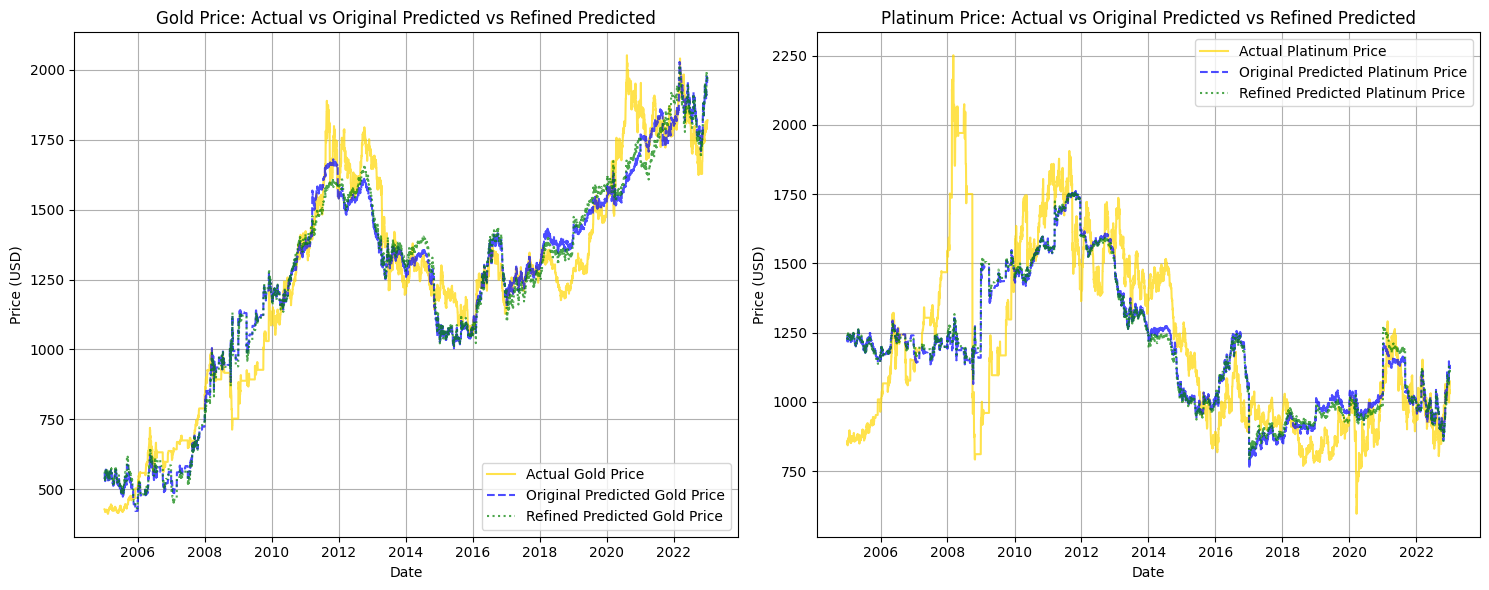

In [23]:
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 元のGoldモデルのAICとR-squaredを保存（bd4784d2で計算されたもの）
original_aic_gold = results_gold.aic
original_r_squared_gold = results_gold.rsquared
original_adj_r_squared_gold = results_gold.rsquared_adj

# 元のPlatinumモデルのAICとR-squaredを保存（bd4784d2で計算されたもの）
original_aic_platinum = results_platinum.aic
original_r_squared_platinum = results_platinum.rsquared
original_adj_r_squared_platinum = results_platinum.rsquared_adj

# --- 変数選択ロジック (相関係数0.1未満の変数を削除) ---

# 金モデルの新しい説明変数を構築
refined_gold_terms = []
# USDJPY, GoldProduction_Tonnes, PlatinumProduction_Tonnes, CPI, FedFundsRate, Party_Republicanの相関をチェック
# ただし、今回はユーザーの指示によりPlatinumとNumWarsはGoldモデルから明示的に除外

# USDJPY
if 'USDJPY' in df_analysis.columns and abs(correlation_matrix.loc['Gold', 'USDJPY']) > 0.1:
    refined_gold_terms.append('USDJPY')

# Party_Republican - 相関行列から値が0.1以下であることを確認済み
if 'Party_Republican' in df_analysis.columns and abs(correlation_matrix.loc['Gold', 'Party_Republican']) > 0.1:
    refined_gold_terms.append('Party_Republican')

# NumWars - ユーザーの指示によりGoldモデルから除外
# if war_column_name is not None and abs(correlation_matrix.loc['Gold', war_column_name]) > 0.1:
#     refined_gold_terms.append(war_column_name)

# GoldProduction_Tonnes
if 'GoldProduction_Tonnes' in df_analysis.columns and abs(correlation_matrix.loc['Gold', 'GoldProduction_Tonnes']) > 0.1:
    refined_gold_terms.append('GoldProduction_Tonnes')

# PlatinumProduction_Tonnes
if 'PlatinumProduction_Tonnes' in df_analysis.columns and abs(correlation_matrix.loc['Gold', 'PlatinumProduction_Tonnes']) > 0.1:
    refined_gold_terms.append('PlatinumProduction_Tonnes')

# CPI
if 'CPI' in df_analysis.columns and abs(correlation_matrix.loc['Gold', 'CPI']) > 0.1:
    refined_gold_terms.append('CPI')

# FedFundsRate
if 'FedFundsRate' in df_analysis.columns and abs(correlation_matrix.loc['Gold', 'FedFundsRate']) > 0.1:
    refined_gold_terms.append('FedFundsRate')

refined_gold_model_formula = 'Gold ~ ' + ' + '.join(refined_gold_terms) if refined_gold_terms else 'Gold ~ 1'

# プラチナモデルの新しい説明変数を構築
refined_platinum_terms = []
# Gold, CPIはプラチナモデルから明示的に除外

# USDJPY
if 'USDJPY' in df_analysis.columns and abs(correlation_matrix.loc['Platinum', 'USDJPY']) > 0.1:
    refined_platinum_terms.append('USDJPY')

# NumWars
if war_column_name is not None and abs(correlation_matrix.loc['Platinum', war_column_name]) > 0.1:
    refined_platinum_terms.append(war_column_name)

# Party_Republican
if 'Party_Republican' in df_analysis.columns and abs(correlation_matrix.loc['Platinum', 'Party_Republican']) > 0.1:
    refined_platinum_terms.append('Party_Republican')

# GoldProduction_Tonnes
if 'GoldProduction_Tonnes' in df_analysis.columns and abs(correlation_matrix.loc['Platinum', 'GoldProduction_Tonnes']) > 0.1:
    refined_platinum_terms.append('GoldProduction_Tonnes')

# PlatinumProduction_Tonnes
if 'PlatinumProduction_Tonnes' in df_analysis.columns and abs(correlation_matrix.loc['Platinum', 'PlatinumProduction_Tonnes']) > 0.1:
    refined_platinum_terms.append('PlatinumProduction_Tonnes')

# FedFundsRate
if 'FedFundsRate' in df_analysis.columns and abs(correlation_matrix.loc['Platinum', 'FedFundsRate']) > 0.1:
    refined_platinum_terms.append('FedFundsRate')

refined_platinum_model_formula = 'Platinum ~ ' + ' + '.join(refined_platinum_terms) if refined_platinum_terms else 'Platinum ~ 1'


# --- 金価格の回帰分析 (最適化モデル) ---
print("\n### 金価格 (Gold) の回帰分析 (最適化モデル) ###")
model_gold_refined = smf.ols(refined_gold_model_formula, data=df_analysis)
results_gold_refined = model_gold_refined.fit()
print(results_gold_refined.summary())

# 回帰式の表示
print("\n回帰式 (Gold, 最適化モデル):")
formula_gold_refined_str = f"Gold = {results_gold_refined.params['Intercept']:.2f}"
for term in refined_gold_terms:
    if term in results_gold_refined.params:
        formula_gold_refined_str += f" + {results_gold_refined.params[term]:.2f} * {term}"
print(formula_gold_refined_str)


# --- プラチナ価格の回帰分析 (最適化モデル) ---
print("\n### プラチナ価格 (Platinum) の回帰分析 (最適化モデル) ###")
model_platinum_refined = smf.ols(refined_platinum_model_formula, data=df_analysis)
results_platinum_refined = model_platinum_refined.fit()
print(results_platinum_refined.summary())

# 回帰式の表示
print("\n回帰式 (Platinum, 最適化モデル):")
formula_platinum_refined_str = f"Platinum = {results_platinum_refined.params['Intercept']:.2f}"
for term in refined_platinum_terms:
    if term in results_platinum_refined.params:
        formula_platinum_refined_str += f" + {results_platinum_refined.params[term]:.2f} * {term}"
print(formula_platinum_refined_str)


# 新しいモデルの評価
df_analysis['Gold_Predicted_Refined'] = results_gold_refined.predict(df_analysis)
df_analysis['Platinum_Predicted_Refined'] = results_platinum_refined.predict(df_analysis)

mae_gold_refined = mean_absolute_error(df_analysis['Gold'], df_analysis['Gold_Predicted_Refined'])
mse_gold_refined = mean_squared_error(df_analysis['Gold'], df_analysis['Gold_Predicted_Refined'])
rmse_gold_refined = np.sqrt(mse_gold_refined)

mae_platinum_refined = mean_absolute_error(df_analysis['Platinum'], df_analysis['Platinum_Predicted_Refined'])
mse_platinum_refined = mean_squared_error(df_analysis['Platinum'], df_analysis['Platinum_Predicted_Refined'])
rmse_platinum_refined = np.sqrt(mse_platinum_refined)

# AICとR-squaredの比較
print("\n### 金・プラチナ価格モデルのAICとR-squaredの比較 ###")
markdown_output_aic_r2_refined = f"""
#### 最適化モデルの評価指標

##### 金価格モデル
*   **元のモデル - AIC:** {original_aic_gold:.0f}, **R-squared:** {original_r_squared_gold:.3f}, **Adj. R-squared:** {original_adj_r_squared_gold:.3f}
*   **最適化モデル - AIC:** {results_gold_refined.aic:.0f}, **R-squared:** {results_gold_refined.rsquared:.3f}, **Adj. R-squared:** {results_gold_refined.rsquared_adj:.3f}
*   **最適化モデル - MAE:** {mae_gold_refined:.2f}, **MSE:** {mse_gold_refined:.2f}, **RMSE:** {rmse_gold_refined:.2f}

##### プラチナ価格モデル
*   **元のモデル - AIC:** {original_aic_platinum:.0f}, **R-squared:** {original_r_squared_platinum:.3f}, **Adj. R-squared:** {original_adj_r_squared_platinum:.3f}
*   **最適化モデル - AIC:** {results_platinum_refined.aic:.0f}, **R-squared:** {results_platinum_refined.rsquared:.3f}, **Adj. R-squared:** {results_platinum_refined.rsquared_adj:.3f}
*   **最適化モデル - MAE:** {mae_platinum_refined:.2f}, **MSE:** {mse_platinum_refined:.2f}, **RMSE:** {rmse_platinum_refined:.2f}

---

**結論 (AICに基づく):**
*   金価格モデル: {'元のモデルよりAICが小さいため、より良いモデルである可能性が高いです。' if results_gold_refined.aic < original_aic_gold else '元のモデルから大きな改善は見られませんでした。'}
*   プラチナ価格モデル: {'元のモデルよりAICが小さいため、より良いモデルである可能性が高いです。' if results_platinum_refined.aic < original_aic_platinum else '元のモデルから大きな改善は見られませんでした。'}
"""
display(Markdown(markdown_output_aic_r2_refined))

# --- 実際の価格と予測価格をプロットして比較 ---
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(df_analysis.index, df_analysis['Gold'], label='Actual Gold Price', color='gold', alpha=0.7)
plt.plot(df_analysis.index, df_analysis['Gold_Predicted'], label='Original Predicted Gold Price', color='blue', linestyle='--', alpha=0.7)
plt.plot(df_analysis.index, df_analysis['Gold_Predicted_Refined'], label='Refined Predicted Gold Price', color='green', linestyle=':', alpha=0.7)
plt.title('Gold Price: Actual vs Original Predicted vs Refined Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df_analysis.index, df_analysis['Platinum'], label='Actual Platinum Price', color='gold', alpha=0.7)
plt.plot(df_analysis.index, df_analysis['Platinum_Predicted'], label='Original Predicted Platinum Price', color='blue', linestyle='--', alpha=0.7)
plt.plot(df_analysis.index, df_analysis['Platinum_Predicted_Refined'], label='Refined Predicted Platinum Price', color='green', linestyle=':', alpha=0.7)
plt.title('Platinum Price: Actual vs Original Predicted vs Refined Predicted')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()